<a href="https://colab.research.google.com/github/loujayne22/superstore-sales-analysis/blob/main/superstore_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
from google.colab import files
uploaded = files.upload()

Saving superstore.csv to superstore (1).csv


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("superstore.csv", encoding="latin-1")
print("Setup OK")
print(df.shape)
print(df.head(2))

Setup OK
(9994, 19)
   Row ID        Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016  Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016  Second Class    CG-12520   

    Segment        Country       City     State Region       Product ID  \
0  Consumer  United States  Henderson  Kentucky  South  FUR-BO-10001798   
1  Consumer  United States  Henderson  Kentucky  South  FUR-CH-10000454   

    Category Sub-Category                                       Product Name  \
0  Furniture    Bookcases                  Bush Somerset Collection Bookcase   
1  Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...   

    Sales  Quantity  Discount    Profit  
0  261.96         2       0.0   41.9136  
1  731.94         3       0.0  219.5820  


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [35]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


In [36]:
print(df.isna().sum())
print("Duplicated rows:", df.duplicated().sum())

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
Duplicated rows: 0


In [37]:
print(df["Category"].unique())
print(df["Region"].unique())
print(df["Segment"].unique())
print(df["Sub-Category"].nunique())

['Furniture' 'Office Supplies' 'Technology']
['South' 'West' 'Central' 'East']
['Consumer' 'Corporate' 'Home Office']
17


In [38]:
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'segment', 'country', 'city', 'state', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [39]:
for col in ["order_date", "ship_date"]:
    df[col] = pd.to_datetime(df[col].str.replace("-", "/"), format="%m/%d/%Y")

print(df[["order_date", "ship_date"]].dtypes)

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


In [40]:
print("Ship before order:", (df["ship_date"] < df["order_date"]).sum())
print(df["order_date"].min(), "to", df["order_date"].max())

Ship before order: 0
2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [41]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["profit_margin"] = df["profit"] / df["sales"]
df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,segment,country,city,state,...,category,sub_category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016,6,0.47


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   segment        9994 non-null   object        
 7   country        9994 non-null   object        
 8   city           9994 non-null   object        
 9   state          9994 non-null   object        
 10  region         9994 non-null   object        
 11  product_id     9994 non-null   object        
 12  category       9994 non-null   object        
 13  sub_category   9994 non-null   object        
 14  product_name   9994 non-null   object        
 15  sales          9994 n

In [43]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
print(f"Total sales: {total_sales:,.0f}")
print(f"Total profit: {total_profit:,.0f}")
print(f"Overall margin: {total_profit / total_sales:.1%}")
print("Number of orders:", df["order_id"].nunique())

df.groupby("year")[["sales", "profit"]].sum().round(0)

Total sales: 2,297,201
Total profit: 286,397
Overall margin: 12.5%
Number of orders: 5009


,sales,profit
year,,
2014,484247.0,49544.0
2015,470533.0,61619.0
2016,609206.0,81795.0
2017,733215.0,93439.0


In [44]:
cat = df.groupby("category")[["sales", "profit"]].sum()
cat["margin"] = cat["profit"] / cat["sales"]
print(cat.round(2))

sub = df.groupby("sub_category")[["sales", "profit"]].sum()
sub["margin"] = sub["profit"] / sub["sales"]
print(sub.sort_values("profit", ascending=False).round(2))

                     sales     profit  margin
category                                     
Furniture        741999.80   18451.27    0.02
Office Supplies  719047.03  122490.80    0.17
Technology       836154.03  145454.95    0.17
                  sales    profit  margin
sub_category                             
Copiers       149528.03  55617.82    0.37
Phones        330007.05  44515.73    0.13
Accessories   167380.32  41936.64    0.25
Paper          78479.21  34053.57    0.43
Binders       203412.73  30221.76    0.15
Chairs        328449.10  26590.17    0.08
Storage       223843.61  21278.83    0.10
Appliances    107532.16  18138.01    0.17
Furnishings    91705.16  13059.14    0.14
Envelopes      16476.40   6964.18    0.42
Art            27118.79   6527.79    0.24
Labels         12486.31   5546.25    0.44
Machines      189238.63   3384.76    0.02
Fasteners       3024.28    949.52    0.31
Supplies       46673.54  -1189.10   -0.03
Bookcases     114880.00  -3472.56   -0.03
Tables        

In [45]:
reg = df.groupby("region")[["sales", "profit"]].sum()
reg["margin"] = reg["profit"] / reg["sales"]
print(reg.round(2))

state_profit = df.groupby("state")["profit"].sum().sort_values()
print("Worst 5 states:\n", state_profit.head(5).round(0))
print("Best 5 states:\n", state_profit.tail(5).round(0))

             sales     profit  margin
region                               
Central  501239.89   39706.36    0.08
East     678781.24   91522.78    0.13
South    391721.90   46749.43    0.12
West     725457.82  108418.45    0.15
Worst 5 states:
 state
Texas            -25729.0
Ohio             -16971.0
Pennsylvania     -15560.0
Illinois         -12608.0
North Carolina    -7491.0
Name: profit, dtype: float64
Best 5 states:
 state
Virginia      18598.0
Michigan      24463.0
Washington    33403.0
New York      74039.0
California    76381.0
Name: profit, dtype: float64


In [46]:
df.pivot_table(index="month", columns="year", values="sales", aggfunc="sum").round(0)

year,2014,2015,2016,2017
month,,,,
1,14237.0,18174.0,18542.0,43971.0
2,4520.0,11951.0,22979.0,20301.0
3,55691.0,38726.0,51716.0,58872.0
4,28295.0,34195.0,38750.0,36522.0
5,23648.0,30132.0,56988.0,44261.0
6,34595.0,24797.0,40345.0,52982.0
7,33946.0,28765.0,39262.0,45264.0
8,27909.0,36898.0,31115.0,63121.0
9,81777.0,64596.0,73410.0,87867.0


In [47]:
sub_profit = df.groupby("sub_category")["profit"].sum().sort_values()
print(sub_profit.head(5).round(0))

df.groupby("discount")["profit"].agg(["count", "sum", "mean"]).round(2)

sub_category
Tables      -17725.0
Bookcases    -3473.0
Supplies     -1189.0
Fasteners      950.0
Machines      3385.0
Name: profit, dtype: float64


,count,sum,mean
discount,,,
0.00,4798,320987.60,66.90
0.10,94,9029.18,96.06
0.15,52,1418.99,27.29
0.20,3657,90337.31,24.70
0.30,227,-10369.28,-45.68
0.32,27,-2391.14,-88.56
0.40,206,-23057.05,-111.93
0.45,11,-2493.11,-226.65
0.50,66,-20506.43,-310.70


In [48]:
print(df.groupby("sub_category")["discount"].mean().sort_values(ascending=False).round(2))
print(df.groupby("state")["discount"].mean().sort_values(ascending=False).head(8).round(2))

sub_category
Binders        0.37
Machines       0.31
Tables         0.26
Bookcases      0.21
Chairs         0.17
Appliances     0.17
Copiers        0.16
Phones         0.15
Furnishings    0.14
Fasteners      0.08
Envelopes      0.08
Accessories    0.08
Supplies       0.08
Paper          0.07
Art            0.07
Storage        0.07
Labels         0.07
Name: discount, dtype: float64
state
Illinois        0.39
Texas           0.37
Pennsylvania    0.33
Ohio            0.32
Colorado        0.32
Arizona         0.30
Florida         0.30
Tennessee       0.29
Name: discount, dtype: float64


In [49]:
state_profit = df.groupby("state")["profit"].sum()
states = ["Illinois", "Texas", "Pennsylvania", "Ohio", "Colorado", "Arizona", "Florida", "Tennessee"]
print(state_profit[states].round(0))

state
Illinois       -12608.0
Texas          -25729.0
Pennsylvania   -15560.0
Ohio           -16971.0
Colorado        -6528.0
Arizona         -3428.0
Florida         -3399.0
Tennessee       -5342.0
Name: profit, dtype: float64


In [50]:
df["high_discount"] = df["discount"] >= 0.30
print(df.groupby("high_discount")[["sales", "profit"]].sum().round(0))
print(df["high_discount"].mean())

                   sales    profit
high_discount                     
False          1934431.0  421773.0
True            362770.0 -135376.0
0.13938363017810687


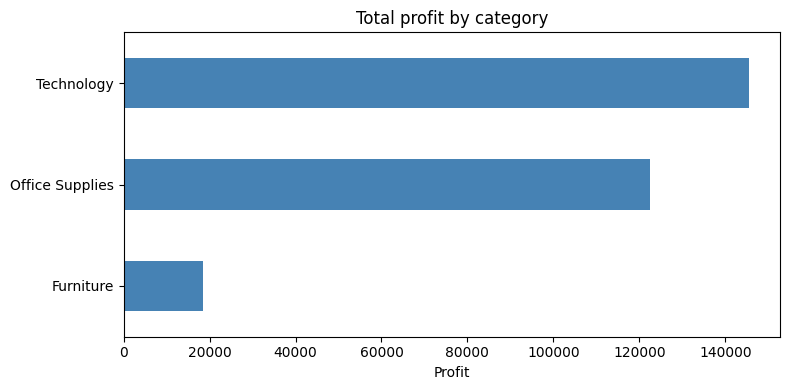

In [51]:
cat_profit = df.groupby("category")["profit"].sum().sort_values()
cat_profit.plot(kind="barh", color="steelblue", figsize=(8, 4))
plt.title("Total profit by category")
plt.xlabel("Profit")
plt.ylabel("")
plt.tight_layout()
plt.show()

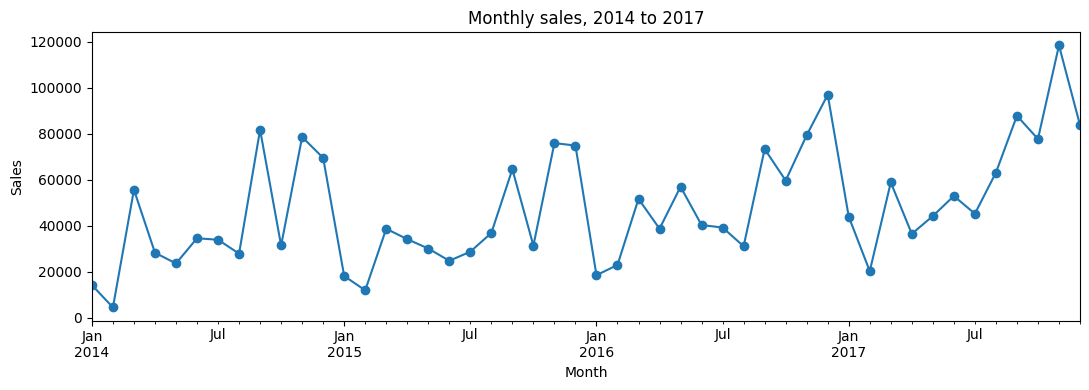

In [52]:
df["order_month"] = df["order_date"].dt.to_period("M")
monthly = df.groupby("order_month")["sales"].sum()
monthly.plot(figsize=(11, 4), marker="o")
plt.title("Monthly sales, 2014 to 2017")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

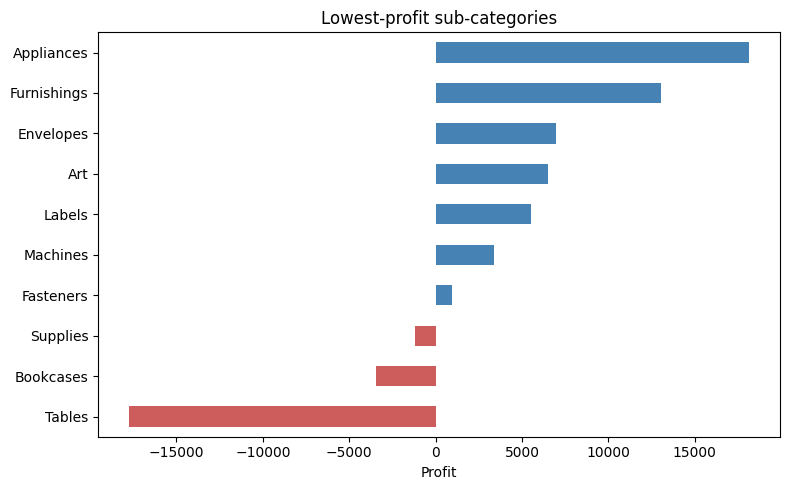

In [53]:
worst = df.groupby("sub_category")["profit"].sum().sort_values().head(10)
colors = ["indianred" if v < 0 else "steelblue" for v in worst]
worst.plot(kind="barh", color=colors, figsize=(8, 5))
plt.title("Lowest-profit sub-categories")
plt.xlabel("Profit")
plt.ylabel("")
plt.tight_layout()
plt.show()

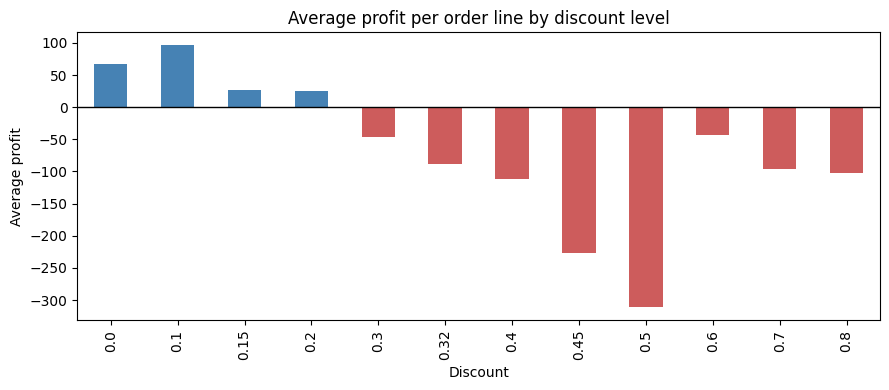

In [54]:
avg_profit = df.groupby("discount")["profit"].mean()
colors = ["indianred" if v < 0 else "steelblue" for v in avg_profit]
avg_profit.plot(kind="bar", color=colors, figsize=(9, 4))
plt.axhline(0, color="black", linewidth=1)
plt.title("Average profit per order line by discount level")
plt.xlabel("Discount")
plt.ylabel("Average profit")
plt.tight_layout()
plt.show()